## Odds ratio analysis of gene loss and duplication

Testing whether the odds that genes in an orthogroup are missing, in single copy, or in multiple copies differs significantly between orb-weavers and non-orb-weavers

#### import modules

In [1]:
import os
import sys
import pandas as pd
from importlib import reload


# Ensure the src directory is in the Python path
scripts = os.path.abspath('')
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# Define paths to data and results directories
data = os.path.join(scripts, "..", "data")
results = os.path.join(scripts, "..", "results")


# Import the odds_ratio_test
import odds_ratio_test as ort

/Users/calvin/anaconda3/envs/orb-selection/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

#### specify input files

In [3]:
genecount_csv = f"{data}/N5.GeneCount.tsv"
orb_list_filename = f"{data}/orbweavers-list.txt"
hog_node_genes_tsv = f"{data}/N5.tsv"

Testing for loss of genes first, using occupancy threshold of 75 (same as HyPhy analysis)

Also using a maximum occupancy of N-3 = 95 so there can be some meaningful comparison of loss between the test groups.

Testing skew, mean, and standard deviation, first using a left-tailed alternative hypothesis

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [00:49<00:00, 200.61it/s]



Bootstrapping counter for MEAN: 0
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8575

Filtering log odds ratio results df for occupancy >= 75, <= 95
and log odds ratio threshold [-1.71889345  1.72025021]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *75* and maximum occupancy *95* 
Analysis run on 2025-07-29 at 17:04:23
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577
True skew: 0.14789325395694103

** BOO

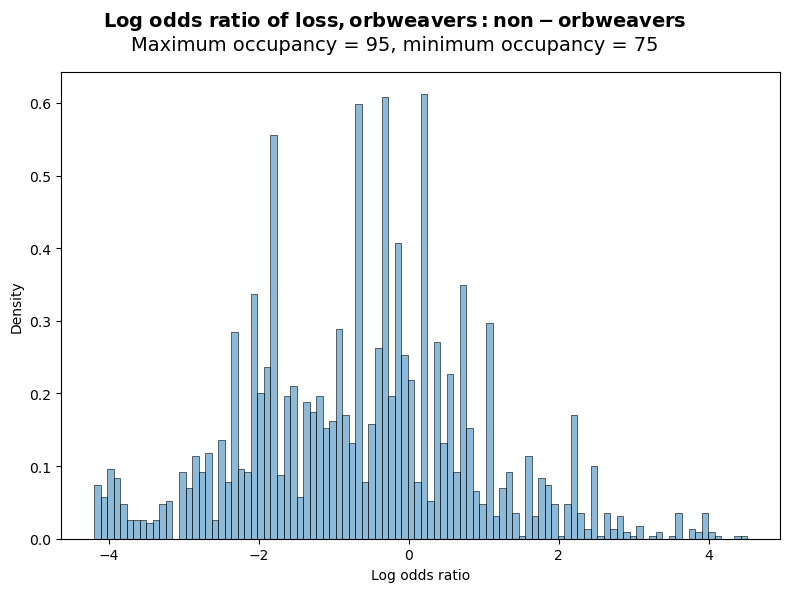

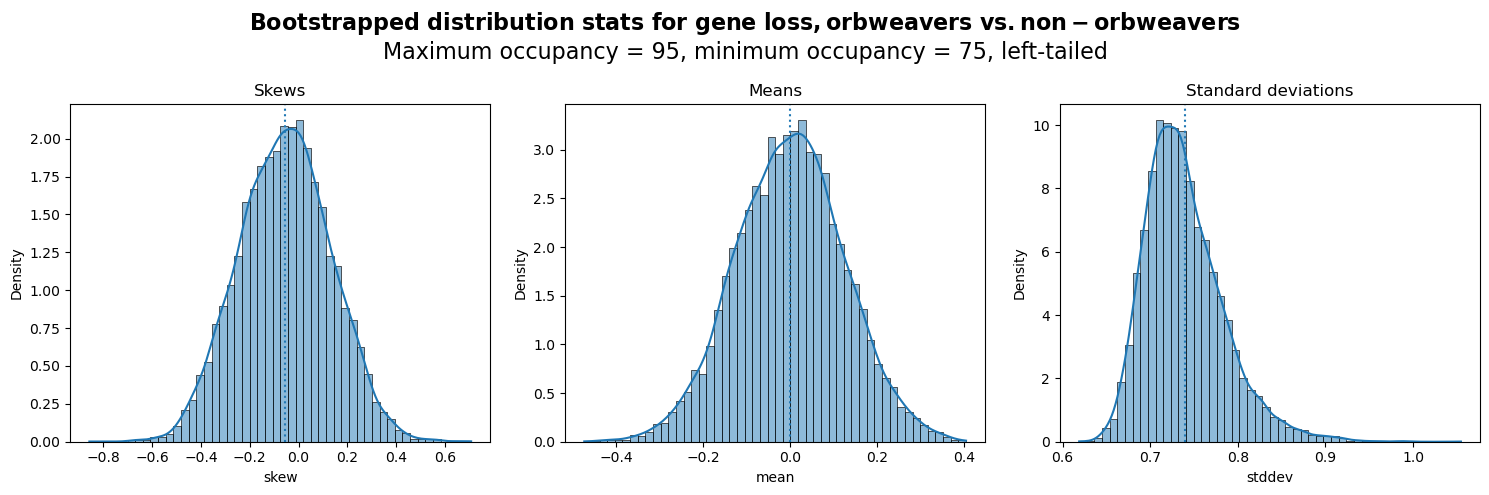

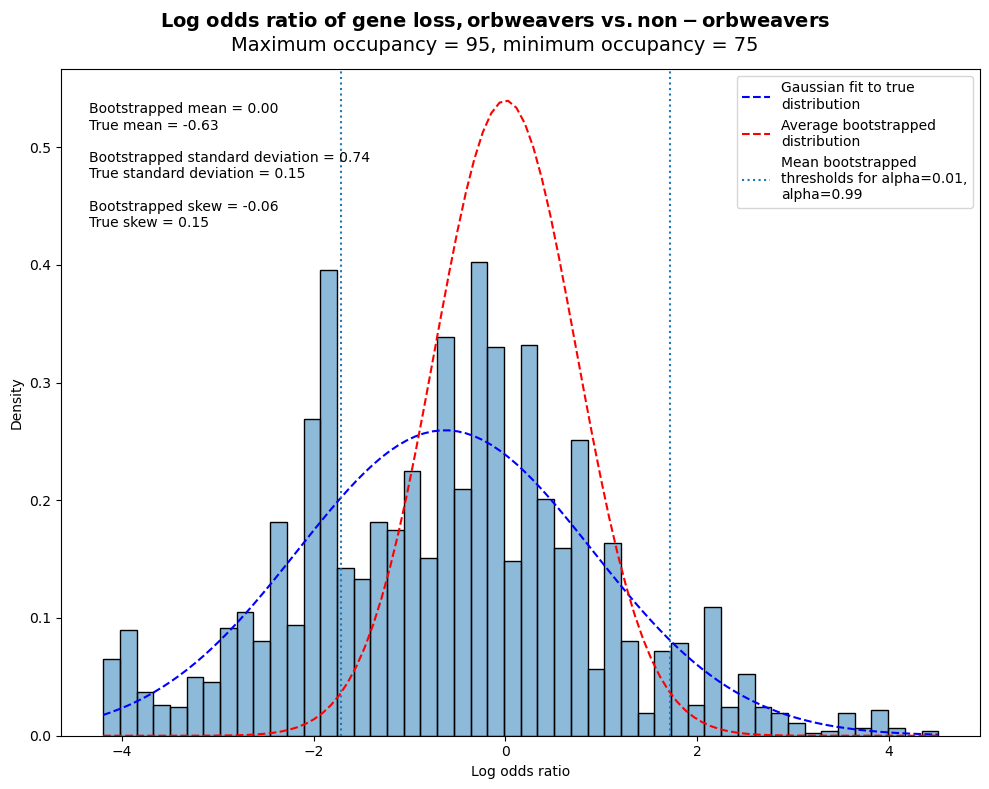

In [4]:
loss_lt_75_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    max_occ=95, 
    alpha=0.01,
    alternative="less",
    species_of_interest="Uloborus_diversus",
    results_dir=f"{results}/odds_ratio_test_75",
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

Same test but right-tailed (two-tailed is not possible with the bootstrapping analysis)

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups EXCEED
the true distribution's statistics (right-tailed)...



100%|██████████| 10000/10000 [00:56<00:00, 177.92it/s]



Bootstrapping counter for MEAN: 10000
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 1406

Filtering log odds ratio results df for occupancy >= 75, <= 95
and log odds ratio threshold [-1.71459453  1.72297032]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (right-tailed)
with minimum occupancy *75* and maximum occupancy *95* 
Analysis run on 2025-07-29 at 17:05:15
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577
True skew: 0.14789325395694103

** BO

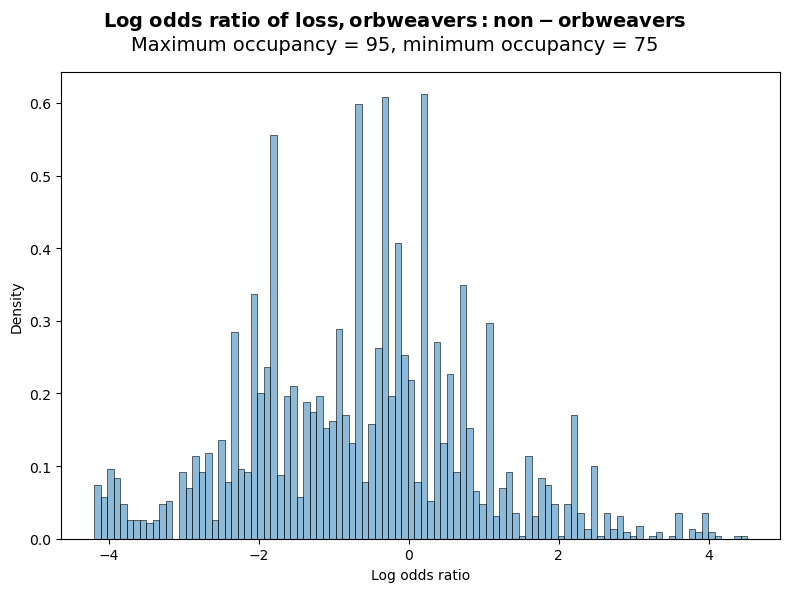

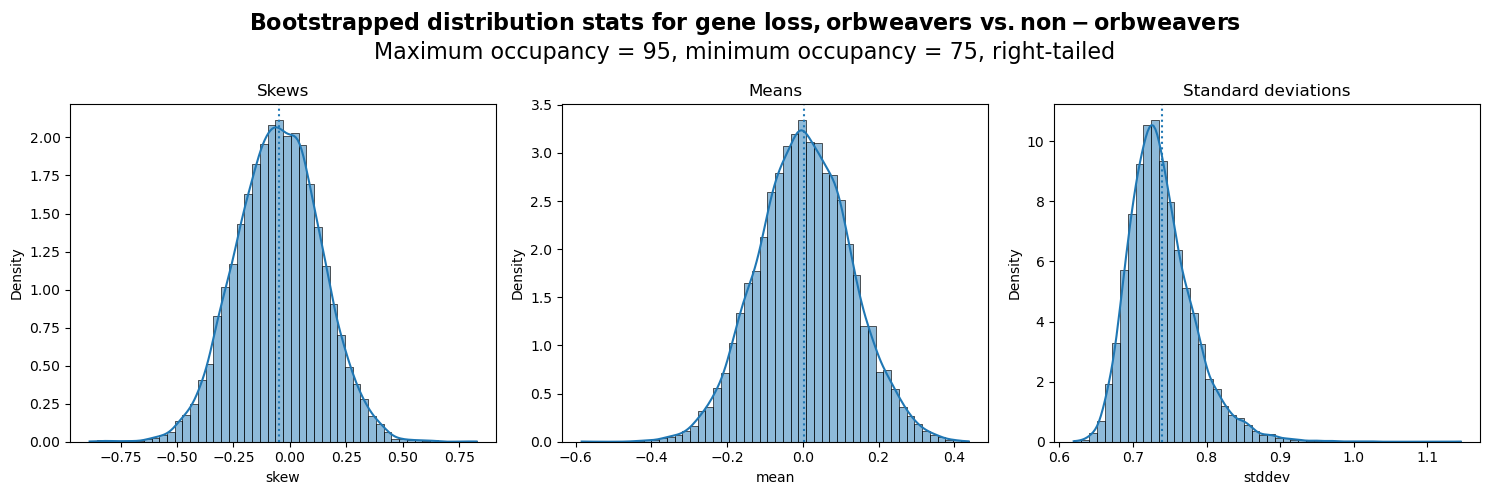

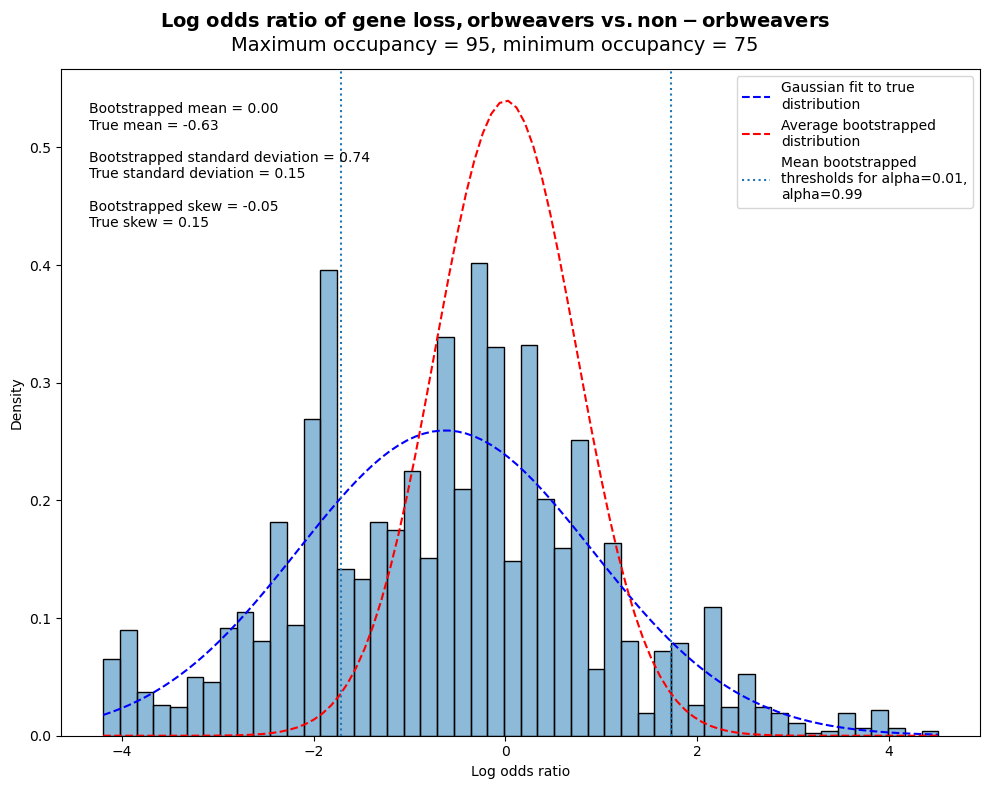

In [5]:
loss_rt_75_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    max_occ=95, 
    alpha=0.01,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
    results_dir=f"{results}/odds_ratio_test_75",
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

Testing for duplication of genes, using minimum occupancy threshold of 75, no max occupancy.

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [00:54<00:00, 184.55it/s]



Bootstrapping counter for MEAN: 1809
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8807

Filtering log odds ratio results df for occupancy >= 75, <= 98
and log odds ratio threshold [-1.45329069  1.45577747]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (left-tailed)
with minimum occupancy *75* and maximum occupancy *no* 
Analysis run on 2025-07-29 at 17:06:14
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5233
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.04746996232571979
True standard deviation: 0.8929220790292889
True skew: 0.05944950339281

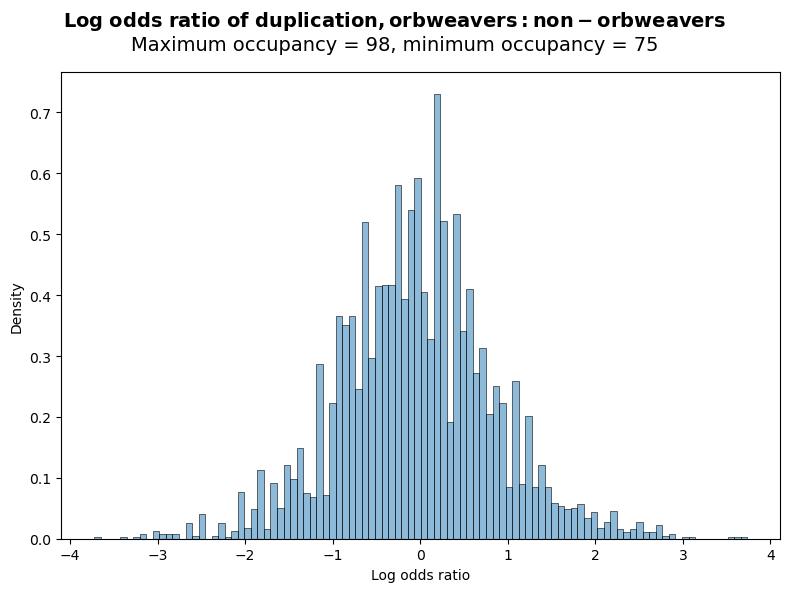

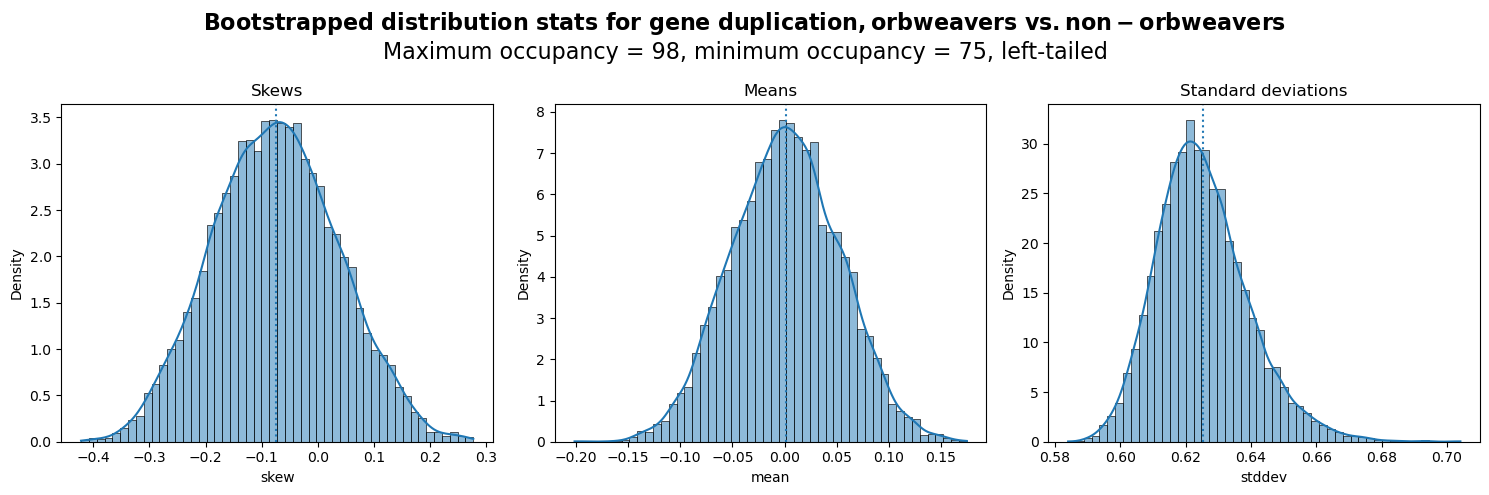

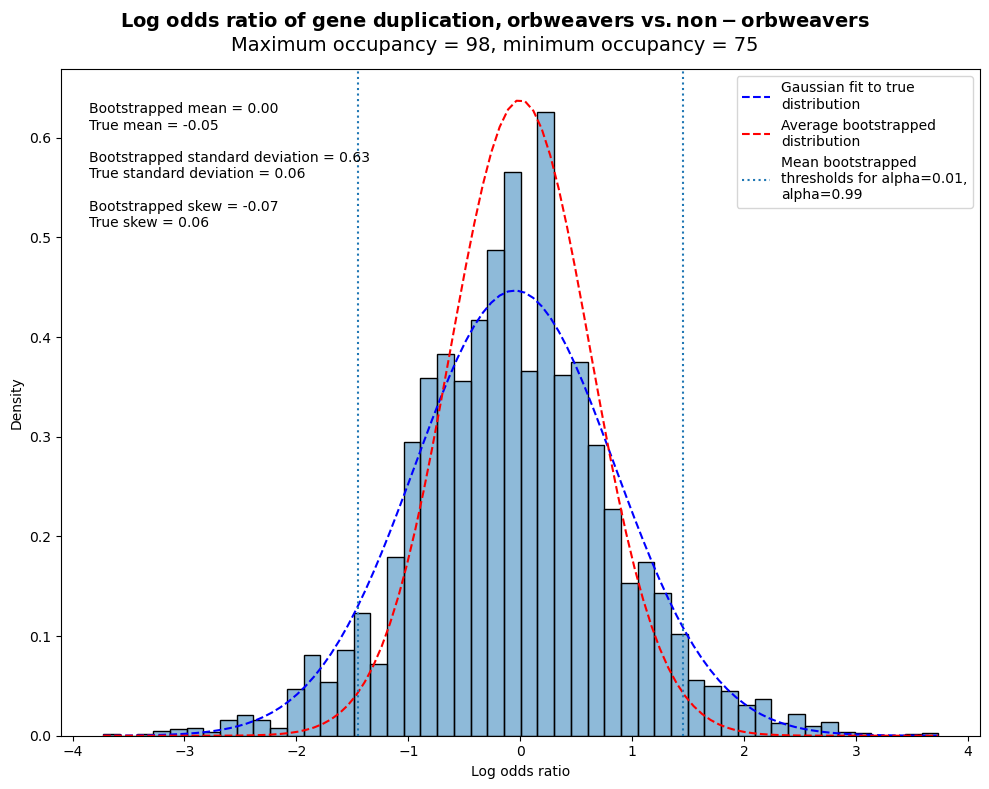

In [6]:
dup_lt_75_98 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "duplication",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    alpha=0.01,
    alternative="less",
    species_of_interest="Uloborus_diversus",
    results_dir=f"{results}/odds_ratio_test_75",
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups EXCEED
the true distribution's statistics (right-tailed)...



100%|██████████| 10000/10000 [00:52<00:00, 189.97it/s]



Bootstrapping counter for MEAN: 8220
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 1186

Filtering log odds ratio results df for occupancy >= 75, <= 98
and log odds ratio threshold [-1.45298419  1.45568497]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (right-tailed)
with minimum occupancy *75* and maximum occupancy *no* 
Analysis run on 2025-07-29 at 17:07:10
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5233
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.04746996232571979
True standard deviation: 0.8929220790292889
True skew: 0.05944950339281756

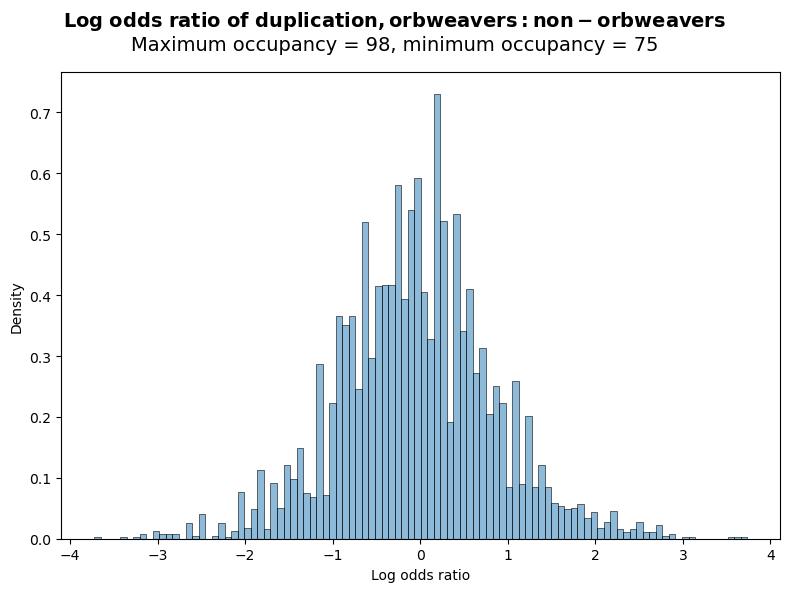

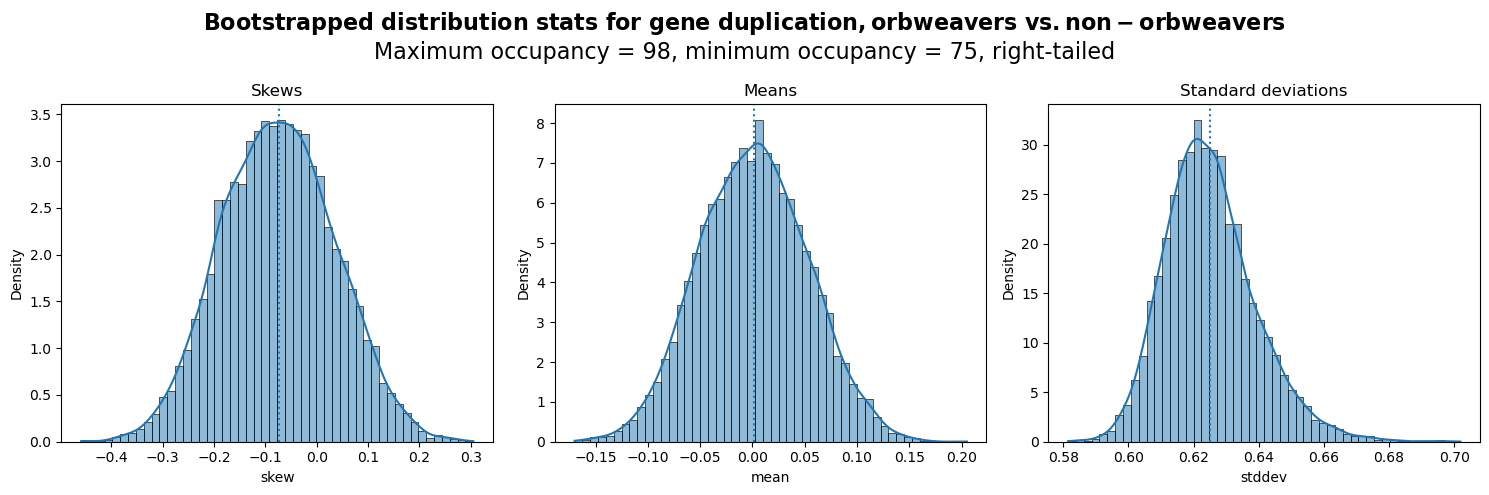

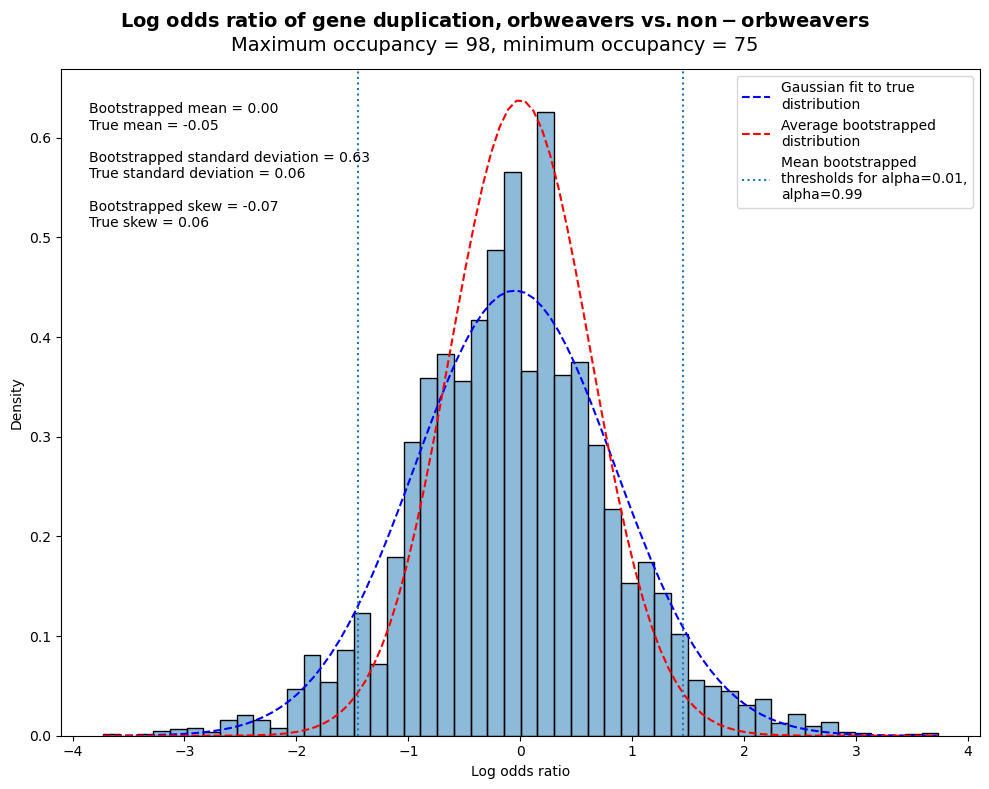

In [7]:
dup_rt_75_98 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "duplication",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    alpha=0.01,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
    results_dir=f"{results}/odds_ratio_test_75",
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

Repeat all 4 tests with occupancy threshold = 50

In [8]:
import itertools
tests=list(itertools.product(["loss","duplication"],["less","greater"]))

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 50 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [00:56<00:00, 175.74it/s]



Bootstrapping counter for MEAN: 0
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8178

Filtering log odds ratio results df for occupancy >= 50, <= 95
and log odds ratio threshold [-1.38433089  1.38801583]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *50* and maximum occupancy *95* 
Analysis run on 2025-07-29 at 17:08:33
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5269
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6629752260879564
True standard deviation: 1.5413813505684821
True skew: 0.19332320037856815

** BOO

100%|██████████| 10000/10000 [00:51<00:00, 192.62it/s]



Bootstrapping counter for MEAN: 10000
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 1910

Filtering log odds ratio results df for occupancy >= 50, <= 95
and log odds ratio threshold [-1.38416918  1.38244859]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (right-tailed)
with minimum occupancy *50* and maximum occupancy *95* 
Analysis run on 2025-07-29 at 17:09:32
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5269
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6629752260879564
True standard deviation: 1.5413813505684821
True skew: 0.19332320037856815

** BO

100%|██████████| 10000/10000 [00:53<00:00, 186.40it/s]



Bootstrapping counter for MEAN: 6643
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8916

Filtering log odds ratio results df for occupancy >= 50, <= 98
and log odds ratio threshold [-1.53070761  1.53478059]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (left-tailed)
with minimum occupancy *50* and maximum occupancy *no* 
Analysis run on 2025-07-29 at 17:10:26
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 7875
Total species: 98
Foreground count: 44
Background count: 54
True mean: 0.025141820982255005
True standard deviation: 0.9948985446732754
True skew: 0.07558266034746

100%|██████████| 10000/10000 [00:49<00:00, 200.01it/s]



Bootstrapping counter for MEAN: 3385
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 1032

Filtering log odds ratio results df for occupancy >= 50, <= 98
and log odds ratio threshold [-1.52977679  1.53390291]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (right-tailed)
with minimum occupancy *50* and maximum occupancy *no* 
Analysis run on 2025-07-29 at 17:11:21
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 7875
Total species: 98
Foreground count: 44
Background count: 54
True mean: 0.025141820982255005
True standard deviation: 0.9948985446732754
True skew: 0.07558266034746924

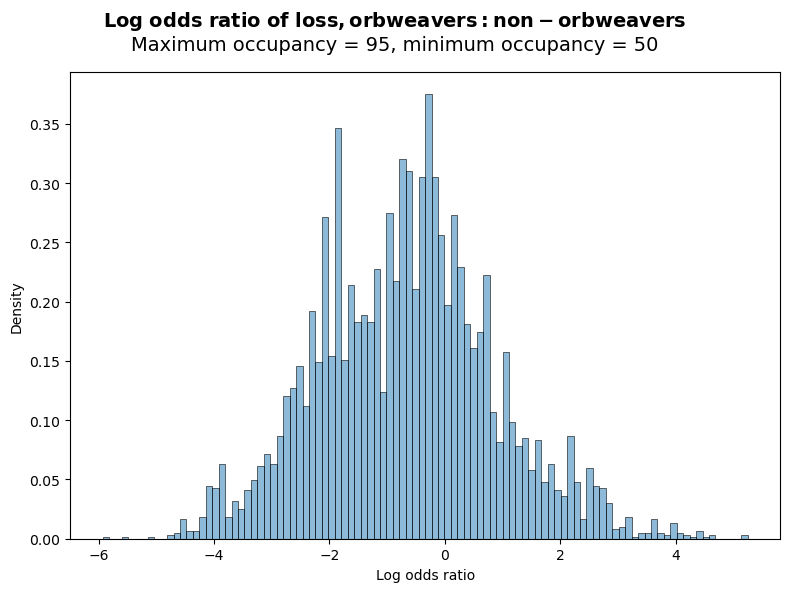

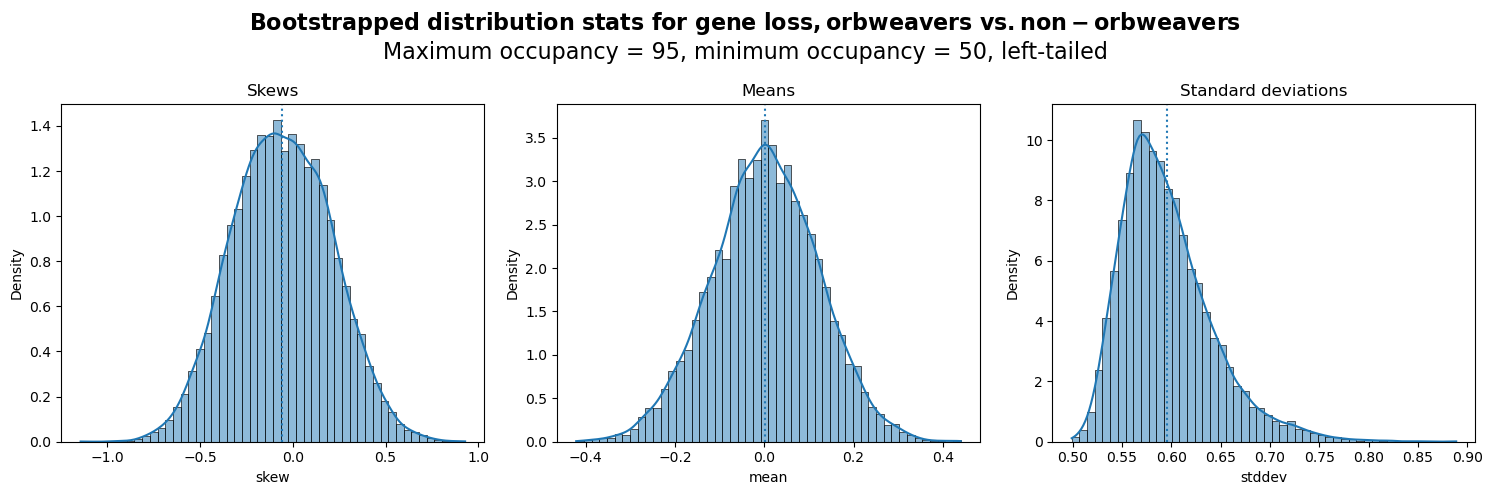

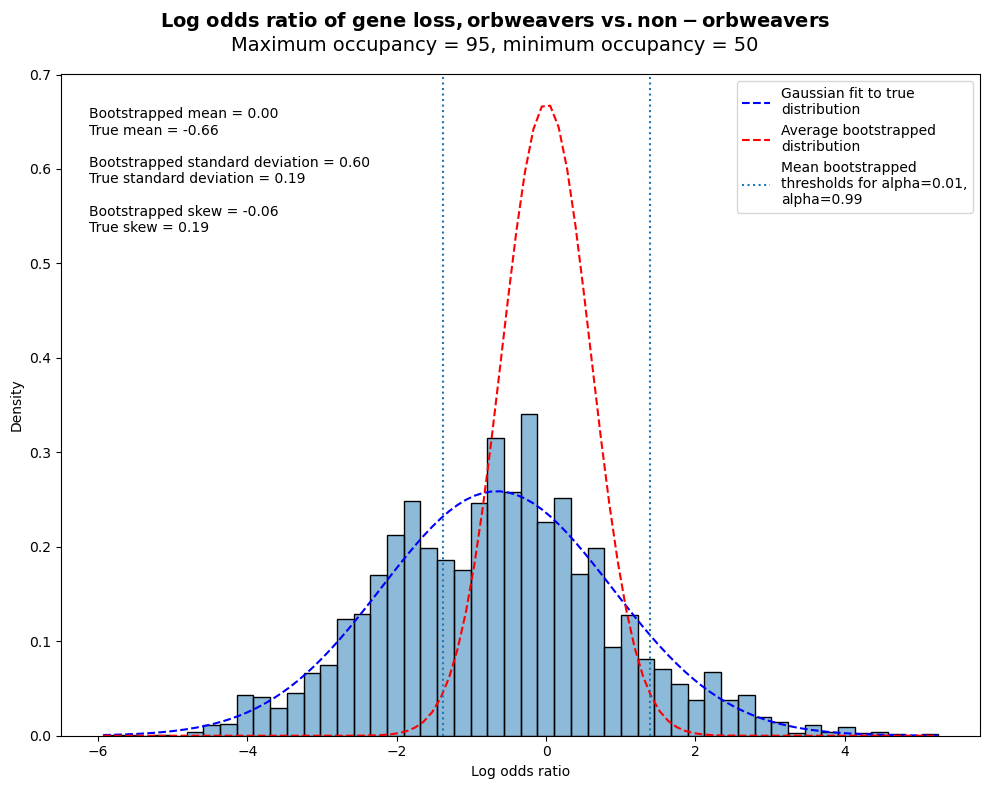

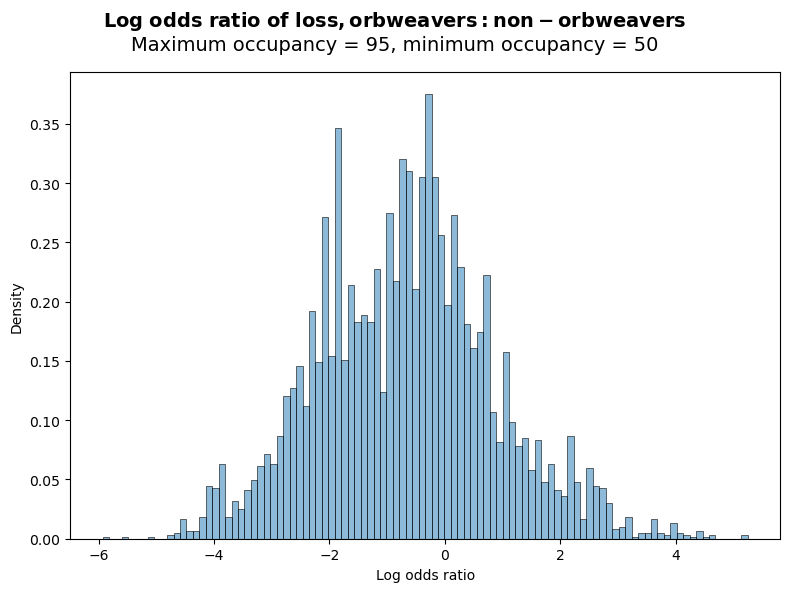

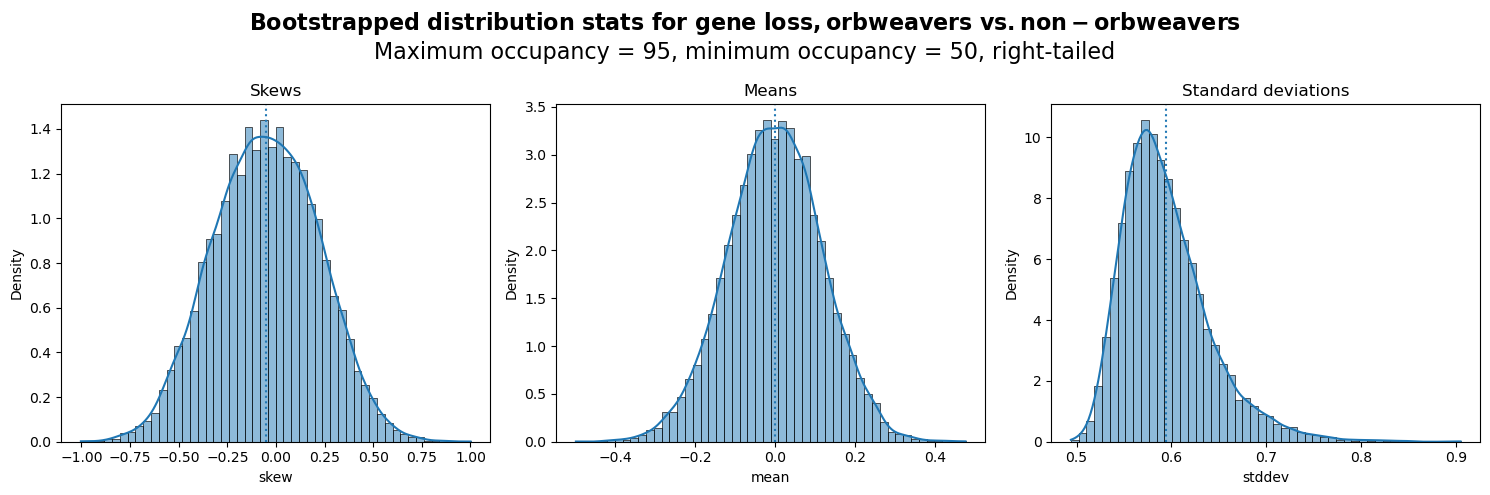

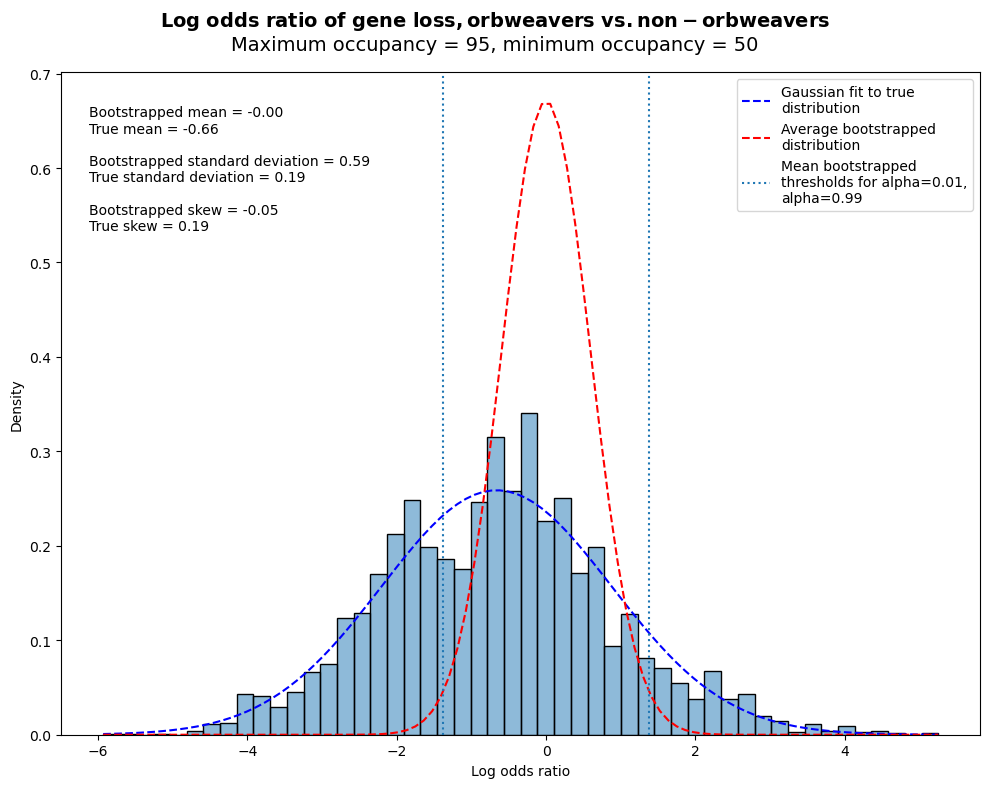

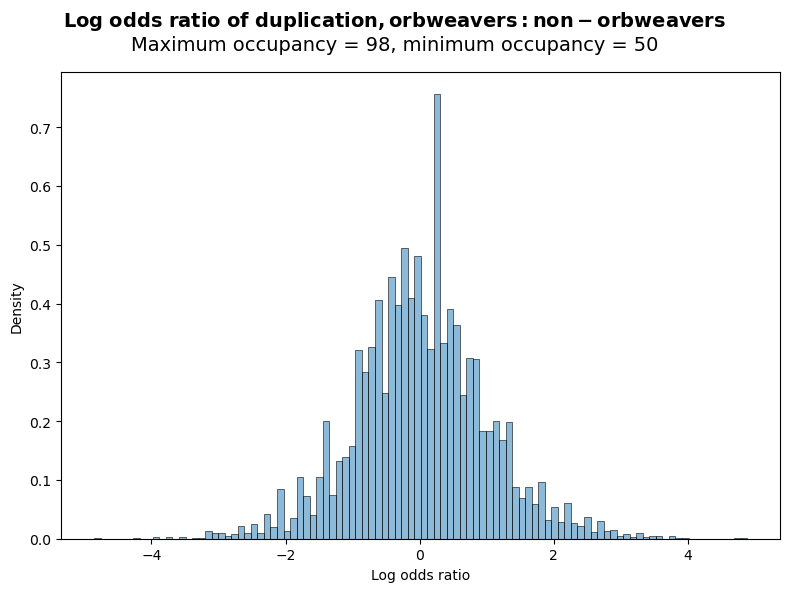

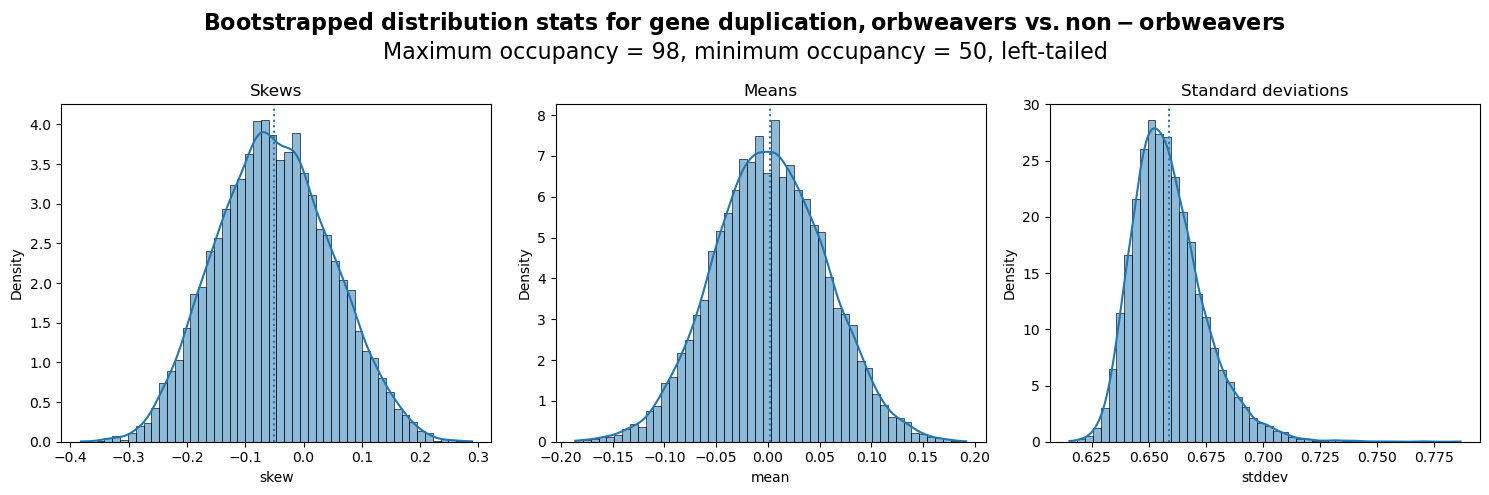

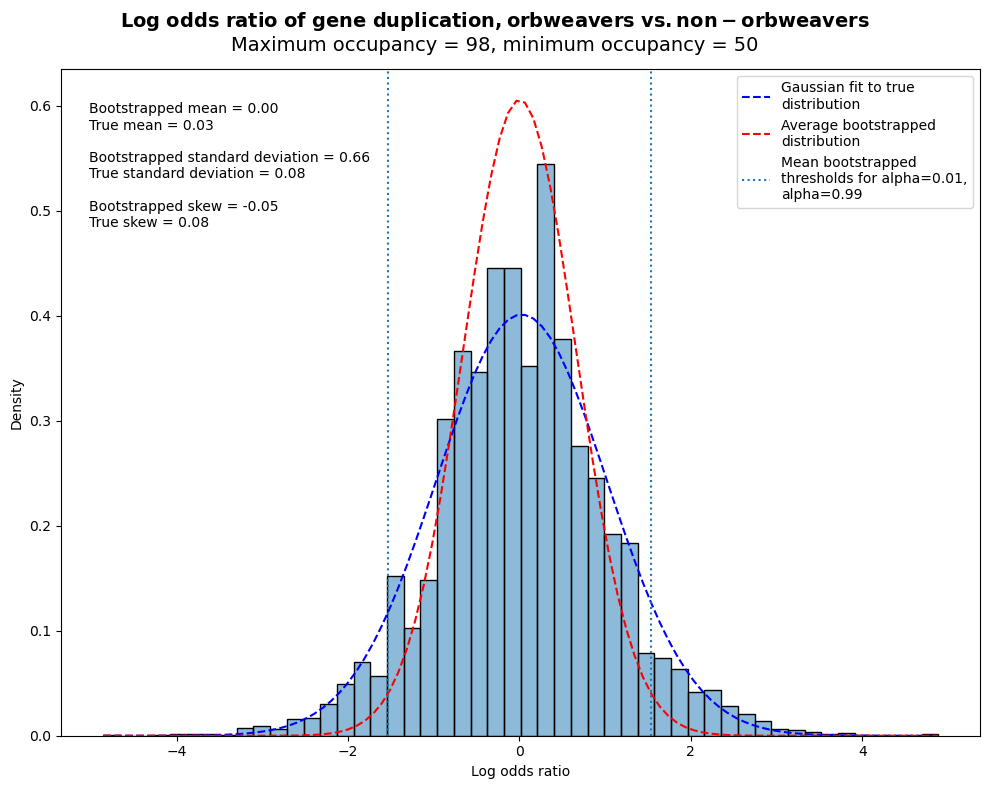

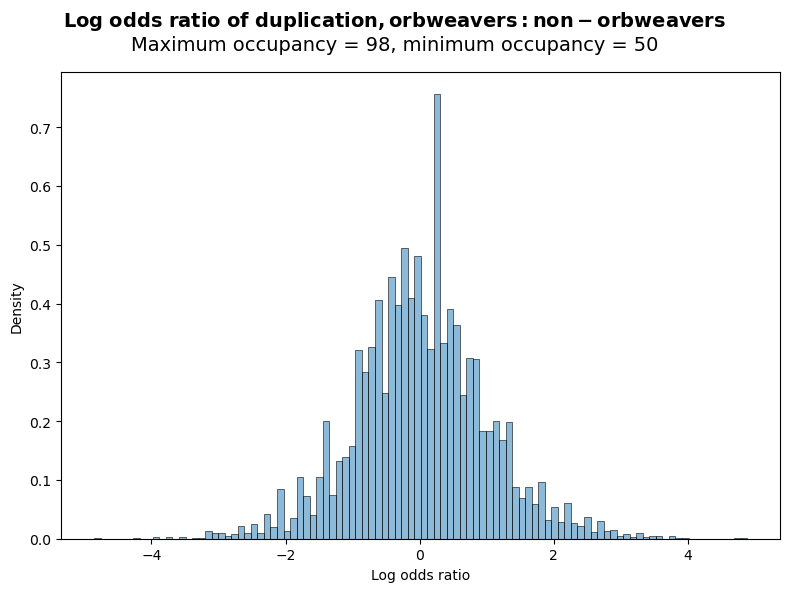

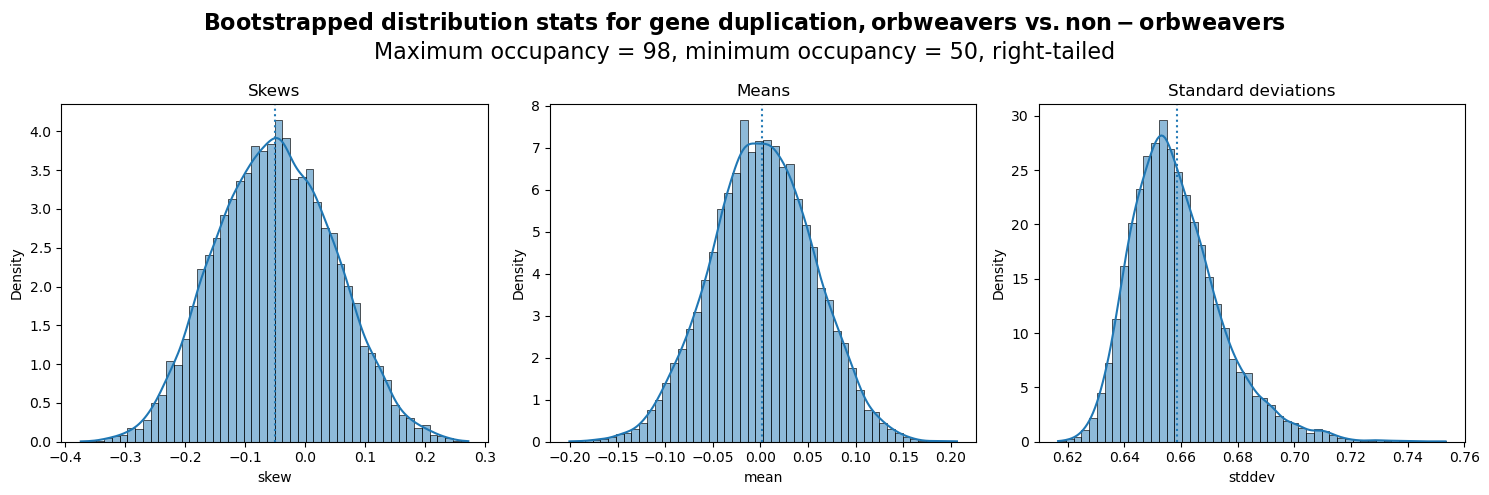

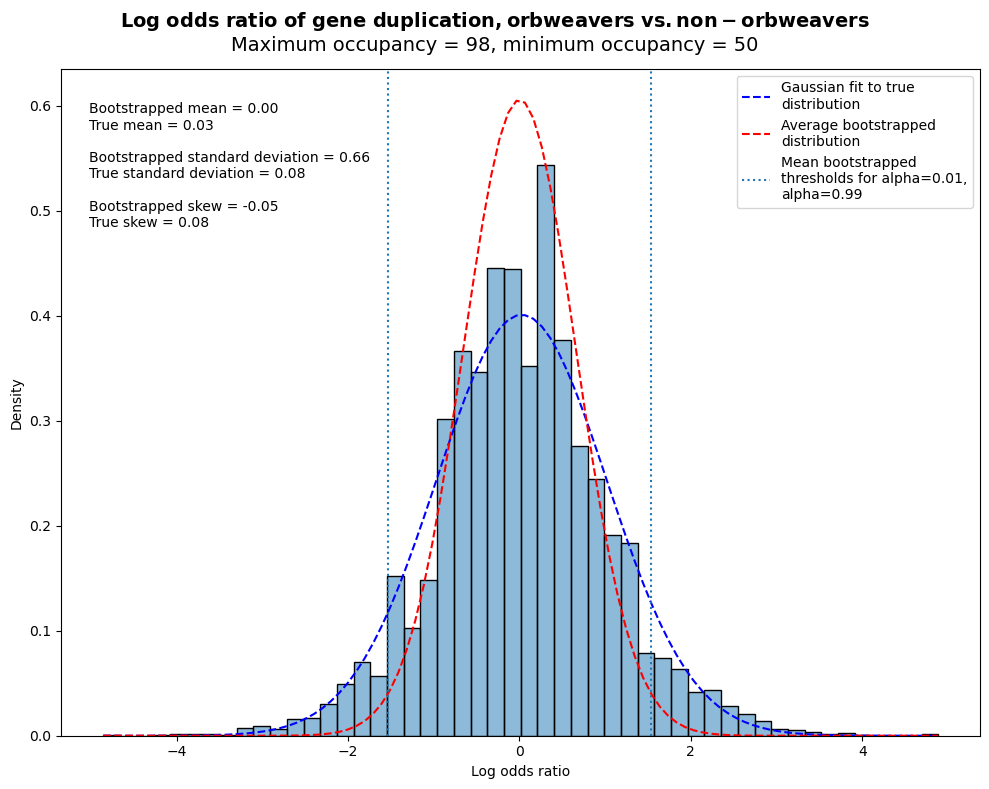

In [10]:
for test in tests:
    if test[0] == "loss":
        max_occ = 95
    else:
        max_occ = None
    ort.odds_ratio_test(
        orb_list_filename,
        hog_node_genes_tsv,
        test=test[0],
        genecount_csv=genecount_csv,
        occupancy_threshold=50,
        alpha=0.01,
        alternative=test[1],
        species_of_interest="Uloborus_diversus",
        results_dir=f'{results}/odds_ratio_test_50',
        fg_name='orbweavers',
        bg_name='non-orbweavers',
        max_occ=max_occ
    )